In [1]:
import numpy as np
from matplotlib import pyplot as plt
import pandas as pd
from pathlib import Path
import pynapple as nap

from scipy.stats import gaussian_kde

from spatial_manifolds.data.binning import get_bin_config
from spatial_manifolds.data.loading import load_session
from spatial_manifolds.detect_grids import *
import warnings
warnings.filterwarnings('ignore')
%load_ext autoreload
%autoreload 2


/Users/harryclark/Documents/spatial-manifolds/src/spatial_manifolds/detect_grids.py:679: SyntaxWarning: "is" with a literal. Did you mean "=="?
  if vr_type is 'MCVR':
/Users/harryclark/Documents/spatial-manifolds/src/spatial_manifolds/detect_grids.py:854: SyntaxWarning: "is" with a literal. Did you mean "=="?
  if vr_type is 'MCVR':
/Users/harryclark/Documents/spatial-manifolds/src/spatial_manifolds/detect_grids.py:1391: SyntaxWarning: "is" with a literal. Did you mean "=="?
  if vr_type is 'MCVR':
/Users/harryclark/Documents/spatial-manifolds/src/spatial_manifolds/detect_grids.py:1448: SyntaxWarning: "is" with a literal. Did you mean "=="?
  if vr_type is 'MCVR':


In [2]:
# Load session
gcs_ = pd.DataFrame()
ngs_ = pd.DataFrame()
ns_ = pd.DataFrame()
sc_ = pd.DataFrame()
ngs_ns_ = pd.DataFrame()
all_ = pd.DataFrame()

mouse_days = {20: [14,15,16,17,18,19,20,21,22,23,24,25,26],
              21: [15,16,17,18,19,20,21,22,23,24,25,26],
              25: [16,17,18,19,20,21,22,23,24,25],
              26: [11,12,13,14,15,16,17,18,19],
              27: [16,17,18,19,20,21,22,23,24,26],
              28: [16,17,18,19,20,21,22,23,25],
              29: [16,17,18,19,20,21,22,23,25],
            }

for mouse, days in mouse_days.items():
    for day in days:

        # remove M22 
        if mouse == 22:
            continue

        [gcs, ngs, ns, sc, ngs_ns, all] = cell_classification_of1(mouse, day)
        _,_,_,_,_,clusters_VR = compute_vr_tcs(mouse, day)

        gcs = load_cluster_locations(clusters_VR, cells=gcs)
        ngs = load_cluster_locations(clusters_VR, cells=ngs)
        ns = load_cluster_locations(clusters_VR, cells=ns)
        sc = load_cluster_locations(clusters_VR, cells=sc)
        ngs_ns = load_cluster_locations(clusters_VR, cells=ngs_ns)
        all = load_cluster_locations(clusters_VR, cells=all)
        
        gcs_ = pd.concat([gcs_, gcs], ignore_index=True)
        ngs_ = pd.concat([ngs_, ngs], ignore_index=True)
        ns_ = pd.concat([ns_, ns], ignore_index=True)
        sc_ = pd.concat([sc_, sc], ignore_index=True)
        ngs_ns_ = pd.concat([ngs_ns_, ngs_ns], ignore_index=True)
        all_ = pd.concat([all_, all], ignore_index=True)

    print(f'there are this many cells at the moment, {len(all_)}')

20 14
optimal travel lag is 1.8518518518518547 cm based on kde of travel at max spatial information
optimal travel lag is 1.8518518518518547 cm
there are 198 non_grid and non_spatial_cells
there are 1 grid_cells
there are 101 non grid spatial cells
there are 97 non spatial cells
there are 0 speed cells
there are 199 cells
for the non-grid spatial cells the unique locations are ['ENTm1' 'ENTm2' 'ENTm3' 'ENTm5']
for the grid cells the unique locations are ['ENTm5']
20 15
optimal travel lag is 2.7527527527527553 cm based on kde of travel at max spatial information
optimal travel lag is 2.7527527527527553 cm
there are 64 non_grid and non_spatial_cells
there are 1 grid_cells
there are 47 non grid spatial cells
there are 17 non spatial cells
there are 0 speed cells
there are 65 cells
for the non-grid spatial cells the unique locations are ['ENTm2' 'ENTm3' 'ENTm5']
for the grid cells the unique locations are ['ENTm3']
20 16
optimal travel lag is 11.861861861861868 cm based on kde of travel at

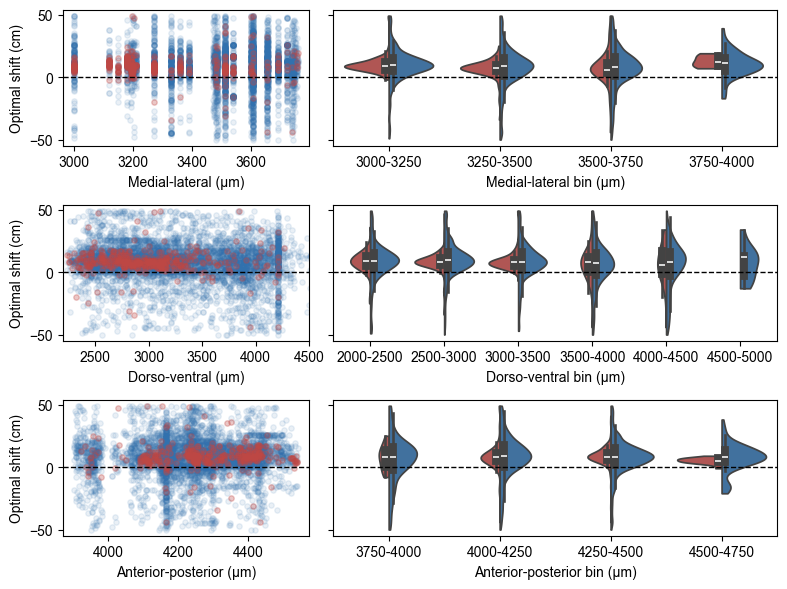

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Prepare data
gcs_df = gcs_.copy()
ngs_df = ngs_.copy()

gcs_df = gcs_df[gcs_df['brain_region'].str.contains('ENT')]
ngs_df = ngs_df[ngs_df['brain_region'].str.contains('ENT')]

# Helper function to get regular bins
def get_regular_bins(series, bin_size=250):
    min_val = int(np.floor(series.min() / bin_size) * bin_size)
    max_val = int(np.ceil(series.max() / bin_size) * bin_size)
    bins = np.arange(min_val, max_val + bin_size, bin_size)
    labels = [f"{bins[i]}-{bins[i+1]}" for i in range(len(bins)-1)]
    return bins, labels

# ML axis binning (250 um)
ml_series = pd.concat([(gcs_df['coord_SCs_x']*-1), (ngs_df['coord_SCs_x']*-1)])
ml_bins, ml_labels = get_regular_bins(ml_series, bin_size=250)
gcs_df['ml_bin'] = pd.cut(gcs_df['coord_SCs_x']*-1, bins=ml_bins, labels=ml_labels, include_lowest=True)
ngs_df['ml_bin'] = pd.cut(ngs_df['coord_SCs_x']*-1, bins=ml_bins, labels=ml_labels, include_lowest=True)

# DV axis binning (500 um)
dv_series = pd.concat([gcs_df['coord_SCs_y'], ngs_df['coord_SCs_y']])
dv_bins, dv_labels = get_regular_bins(dv_series, bin_size=500)
gcs_df['dv_bin'] = pd.cut(gcs_df['coord_SCs_y'], bins=dv_bins, labels=dv_labels, include_lowest=True)
ngs_df['dv_bin'] = pd.cut(ngs_df['coord_SCs_y'], bins=dv_bins, labels=dv_labels, include_lowest=True)

# AP axis binning (250 um)
ap_series = pd.concat([gcs_df['coord_SCs_z'], ngs_df['coord_SCs_z']])
ap_bins, ap_labels = get_regular_bins(ap_series, bin_size=250)
gcs_df['ap_bin'] = pd.cut(gcs_df['coord_SCs_z'], bins=ap_bins, labels=ap_labels, include_lowest=True)
ngs_df['ap_bin'] = pd.cut(ngs_df['coord_SCs_z'], bins=ap_bins, labels=ap_labels, include_lowest=True)

gcs_df['group'] = 'GCS'
ngs_df['group'] = 'NGS'

# Combine for violin plots
combined = pd.concat([gcs_df, ngs_df], ignore_index=True)

fig, axes = plt.subplots(3, 2, figsize=(8, 6), width_ratios=[1,1.8], sharey='row')

# ML scatter
axes[0, 0].scatter(ngs_df['coord_SCs_x']*-1, ngs_df['optimal_travel_lag'], color='#3171ae', alpha=0.1, s=15, label='NGS')
axes[0, 0].scatter(gcs_df['coord_SCs_x']*-1, gcs_df['optimal_travel_lag'], color='#c04744', alpha=0.3, s=15, label='GCS')
axes[0, 0].axhline(0, color='black', linestyle='--', linewidth=1)
axes[0, 0].set_ylabel('Optimal shift (cm)')
axes[0, 0].set_xlabel('Medial-lateral (µm)')

# ML binned violin plot
sns.violinplot(
    data=combined, 
    x='ml_bin', 
    y='optimal_travel_lag', 
    hue='group', 
    split=True, 
    palette={'GCS': '#c04744', 'NGS': '#3171ae'}, 
    ax=axes[0, 1], 
    cut=0
)
axes[0, 1].axhline(0, color='black', linestyle='--', linewidth=1)
axes[0, 1].set_xlabel('Medial-lateral bin (µm)')
axes[0, 1].get_legend().remove()  # Remove legend from violin plot

# DV scatter
axes[1, 0].scatter(ngs_df['coord_SCs_y'], ngs_df['optimal_travel_lag'], color='#3171ae', alpha=0.1, s=15, label='NGS')
axes[1, 0].scatter(gcs_df['coord_SCs_y'], gcs_df['optimal_travel_lag'], color='#c04744', alpha=0.3, s=15, label='GCS')
axes[1, 0].axhline(0, color='black', linestyle='--', linewidth=1)
axes[1, 0].set_ylabel('Optimal shift (cm)')
axes[1, 0].set_xlabel('Dorso-ventral (µm)')
axes[1, 0].set_xlim(2200, 4500)

# DV binned violin plot
sns.violinplot(
    data=combined, 
    x='dv_bin', 
    y='optimal_travel_lag', 
    hue='group', 
    split=True, 
    palette={'GCS': '#c04744', 'NGS': '#3171ae'}, 
    ax=axes[1, 1], 
    cut=0
)
axes[1, 1].axhline(0, color='black', linestyle='--', linewidth=1)
axes[1, 1].set_xlabel('Dorso-ventral bin (µm)')
axes[1, 1].get_legend().remove()  # Remove legend from violin plot

# AP scatter
axes[2, 0].scatter(ngs_df['coord_SCs_z'], ngs_df['optimal_travel_lag'], color='#3171ae', alpha=0.1, s=15, label='NGS')
axes[2, 0].scatter(gcs_df['coord_SCs_z'], gcs_df['optimal_travel_lag'], color='#c04744', alpha=0.3, s=15, label='GCS')
axes[2, 0].axhline(0, color='black', linestyle='--', linewidth=1)
axes[2, 0].set_ylabel('Optimal shift (cm)')
axes[2, 0].set_xlabel('Anterior-posterior (µm)')

# AP binned violin plot
sns.violinplot(
    data=combined, 
    x='ap_bin', 
    y='optimal_travel_lag', 
    hue='group', 
    split=True,
    palette={'GCS': '#c04744', 'NGS': '#3171ae'}, 
    ax=axes[2, 1], 
    cut=0
)
axes[2, 1].axhline(0, color='black', linestyle='--', linewidth=1)
axes[2, 1].set_xlabel('Anterior-posterior bin (µm)')
axes[2, 1].set_ylabel('Optimal shift (cm)')
axes[2, 1].get_legend().remove()  # Remove legend from violin plot

plt.tight_layout()
plt.savefig('/Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_2_predictive_coding/optimal_lag_by_anatomical_axis.pdf', bbox_inches='tight')
plt.show()

In [4]:
import pandas as pd
import statsmodels.formula.api as smf

# Prepare data
gcs_df = gcs_.copy()
ngs_df = ngs_.copy()

gcs_df = gcs_df[gcs_df['brain_region'].str.contains('ENT')]
ngs_df = ngs_df[ngs_df['brain_region'].str.contains('ENT')]

gcs_df['group'] = 'GCS'
ngs_df['group'] = 'NGS'

# Combine grid and non-grid cells for analysis
df = pd.concat([gcs_df, ngs_df], ignore_index=True)

# Make sure cluster_id and day are strings for variance components
df['cluster_id'] = df['cluster_id'].astype(str)
df['day'] = df['day'].astype(str)
df['mouse'] = df['mouse'].astype(str)

# Variance components for hierarchical random effects
vc = {
    "day": "0 + C(day)",
    "cluster": "0 + C(cluster_id)"
}

# ML axis (medial-lateral, use coord_SCs_x)
ml_df = df.dropna(subset=['coord_SCs_x'])
model_ml = smf.mixedlm(
    "optimal_travel_lag ~ group * coord_SCs_x",
    ml_df,
    groups=ml_df["mouse"],         # top-level random effect
    vc_formula=vc                  # nested random effects
)
result_ml = model_ml.fit()
print("ML axis model:")
print(result_ml.summary())

# DV axis (dorso-ventral, use coord_SCs_y)
dv_df = df.dropna(subset=['coord_SCs_y'])
model_dv = smf.mixedlm(
    "optimal_travel_lag ~ group * coord_SCs_y",
    dv_df,
    groups=dv_df["mouse"],
    vc_formula=vc
)
result_dv = model_dv.fit()
print("DV axis model:")
print(result_dv.summary())

# AP axis (anterior-posterior, use coord_SCs_z)
ap_df = df.dropna(subset=['coord_SCs_z'])
model_ap = smf.mixedlm(
    "optimal_travel_lag ~ group * coord_SCs_z",
    ap_df,
    groups=ap_df["mouse"],
    vc_formula=vc
)
result_ap = model_ap.fit()
print("AP axis model:")
print(result_ap.summary())

ML axis model:
               Mixed Linear Model Regression Results
Model:              MixedLM  Dependent Variable:  optimal_travel_lag
No. Observations:   5378     Method:              REML              
No. Groups:         7        Scale:               217.0534          
Min. group size:    263      Log-Likelihood:      -22230.1226       
Max. group size:    1756     Converged:           Yes               
Mean group size:    768.3                                           
--------------------------------------------------------------------
                         Coef.  Std.Err.   z    P>|z|  [0.025 0.975]
--------------------------------------------------------------------
Intercept                10.089   13.388  0.754 0.451 -16.151 36.329
group[T.NGS]             -5.335   13.129 -0.406 0.685 -31.068 20.398
coord_SCs_x               0.001    0.004  0.243 0.808  -0.007  0.009
group[T.NGS]:coord_SCs_x -0.002    0.004 -0.429 0.668  -0.009  0.006
cluster Var               3.697    

ML intercepts: 10.089159286052842 4.7545243533403525
DV intercepts: 11.53414111328092 12.024249265296985
AP intercepts: -11.778302976043754 1.0116690047698391


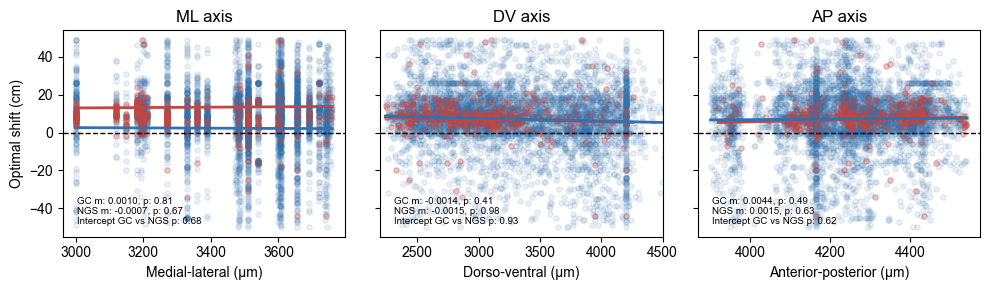

In [5]:
# ...existing code...
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf

# Prepare data
gcs_df = gcs_.copy()
ngs_df = ngs_.copy()

gcs_df = gcs_df[gcs_df['brain_region'].str.contains('ENT')]
ngs_df = ngs_df[ngs_df['brain_region'].str.contains('ENT')]

gcs_df['group'] = 'GC'
ngs_df['group'] = 'NGS'

# Combine grid and non-grid cells for analysis
df = pd.concat([gcs_df, ngs_df], ignore_index=True)
df['cluster_id'] = df['cluster_id'].astype(str)
df['day'] = df['day'].astype(str)
df['mouse'] = df['mouse'].astype(str)

vc = {
    "day": "0 + C(day)",
    "cluster": "0 + C(cluster_id)"
}

# ML axis stats
ml_df = df.dropna(subset=['coord_SCs_x'])
model_ml = smf.mixedlm(
    "optimal_travel_lag ~ group * coord_SCs_x",
    ml_df,
    groups=ml_df["mouse"],
    vc_formula=vc
)
result_ml = model_ml.fit()
ml_intercept = result_ml.params['Intercept']
ml_gcs_slope = result_ml.params['coord_SCs_x']
ml_ngs_slope = result_ml.params['coord_SCs_x'] + result_ml.params.get('group[T.NGS]:coord_SCs_x', 0)
ml_ngs_intercept = ml_intercept + result_ml.params.get('group[T.NGS]', 0)
ml_gcs_p = result_ml.pvalues.get('coord_SCs_x', np.nan)
ml_ngs_p = result_ml.pvalues.get('group[T.NGS]:coord_SCs_x', np.nan)
ml_intercept_p = result_ml.pvalues.get('group[T.NGS]', np.nan)
print('ML intercepts:', ml_intercept, ml_ngs_intercept)

# DV axis stats
dv_df = df.dropna(subset=['coord_SCs_y'])
model_dv = smf.mixedlm(
    "optimal_travel_lag ~ group * coord_SCs_y",
    dv_df,
    groups=dv_df["mouse"],
    vc_formula=vc
)
result_dv = model_dv.fit()
dv_intercept = result_dv.params['Intercept']
dv_gcs_slope = result_dv.params['coord_SCs_y']
dv_ngs_slope = result_dv.params['coord_SCs_y'] + result_dv.params.get('group[T.NGS]:coord_SCs_y', 0)
dv_ngs_intercept = dv_intercept + result_dv.params.get('group[T.NGS]', 0)
dv_gcs_p = result_dv.pvalues.get('coord_SCs_y', np.nan)
dv_ngs_p = result_dv.pvalues.get('group[T.NGS]:coord_SCs_y', np.nan)
dv_intercept_p = result_dv.pvalues.get('group[T.NGS]', np.nan)
print('DV intercepts:', dv_intercept, dv_ngs_intercept)

# AP axis stats
ap_df = df.dropna(subset=['coord_SCs_z'])
model_ap = smf.mixedlm(
    "optimal_travel_lag ~ group * coord_SCs_z",
    ap_df,
    groups=ap_df["mouse"],
    vc_formula=vc
)
result_ap = model_ap.fit()
ap_intercept = result_ap.params['Intercept']
ap_gcs_slope = result_ap.params['coord_SCs_z']
ap_ngs_slope = result_ap.params['coord_SCs_z'] + result_ap.params.get('group[T.NGS]:coord_SCs_z', 0)
ap_ngs_intercept = ap_intercept + result_ap.params.get('group[T.NGS]', 0)
ap_gcs_p = result_ap.pvalues.get('coord_SCs_z', np.nan)
ap_ngs_p = result_ap.pvalues.get('group[T.NGS]:coord_SCs_z', np.nan)
ap_intercept_p = result_ap.pvalues.get('group[T.NGS]', np.nan)
print('AP intercepts:', ap_intercept, ap_ngs_intercept)

# --- Create 3 columns, 1 row plot: only scatters and LMM fits ---
fig, axes = plt.subplots(1, 3, figsize=(10, 3), sharey=True)

# ML axis
axes[0].scatter(ngs_df['coord_SCs_x']*-1, ngs_df['optimal_travel_lag'], color='#3171ae', alpha=0.1, s=15, label='NGS')
axes[0].scatter(gcs_df['coord_SCs_x']*-1, gcs_df['optimal_travel_lag'], color='#c04744', alpha=0.3, s=15, label='GCS')
axes[0].axhline(0, color='black', linestyle='--', linewidth=1)
axes[0].set_xlabel('Medial-lateral (µm)')
axes[0].set_ylabel('Optimal shift (cm)')
axes[0].set_title('ML axis')

ml_x_gcs = np.linspace((gcs_df['coord_SCs_x']*-1).min(), (gcs_df['coord_SCs_x']*-1).max(), 100)
ml_x_ngs = np.linspace((ngs_df['coord_SCs_x']*-1).min(), (ngs_df['coord_SCs_x']*-1).max(), 100)
axes[0].plot(ml_x_gcs, ml_intercept + ml_gcs_slope * ml_x_gcs, color='#c04744', linewidth=2)
axes[0].plot(ml_x_ngs, ml_ngs_intercept + ml_ngs_slope * ml_x_ngs, color='#3171ae', linewidth=2)
axes[0].text(
    0.05, 0.05,
    f"GC m: {ml_gcs_slope:.4f}, p: {ml_gcs_p:.2f}\n"
    f"NGS m: {ml_ngs_slope:.4f}, p: {ml_ngs_p:.2f}\n"
    f"Intercept GC vs NGS p: {ml_intercept_p:.2g}",
    ha='left', va='bottom', fontsize=7, color='black', transform=axes[0].transAxes
)

# DV axis
axes[1].scatter(ngs_df['coord_SCs_y'], ngs_df['optimal_travel_lag'], color='#3171ae', alpha=0.1, s=15, label='NGS')
axes[1].scatter(gcs_df['coord_SCs_y'], gcs_df['optimal_travel_lag'], color='#c04744', alpha=0.3, s=15, label='GCS')
axes[1].axhline(0, color='black', linestyle='--', linewidth=1)
axes[1].set_xlabel('Dorso-ventral (µm)')
axes[1].set_title('DV axis')
axes[1].set_xlim(2200, 4500)

dv_x_gcs = np.linspace(gcs_df['coord_SCs_y'].min(), gcs_df['coord_SCs_y'].max(), 100)
dv_x_ngs = np.linspace(ngs_df['coord_SCs_y'].min(), ngs_df['coord_SCs_y'].max(), 100)
axes[1].plot(dv_x_gcs, dv_intercept + dv_gcs_slope * dv_x_gcs, color='#c04744', linewidth=2)
axes[1].plot(dv_x_ngs, dv_ngs_intercept + dv_ngs_slope * dv_x_ngs, color='#3171ae', linewidth=2)
axes[1].text(
    0.05, 0.05,
    f"GC m: {dv_gcs_slope:.4f}, p: {dv_gcs_p:.2f}\n"
    f"NGS m: {dv_ngs_slope:.4f}, p: {dv_ngs_p:.2f}\n"
    f"Intercept GC vs NGS p: {dv_intercept_p:.2g}",
    ha='left', va='bottom', fontsize=7, color='black', transform=axes[1].transAxes
)

# AP axis
axes[2].scatter(ngs_df['coord_SCs_z'], ngs_df['optimal_travel_lag'], color='#3171ae', alpha=0.1, s=15, label='NGS')
axes[2].scatter(gcs_df['coord_SCs_z'], gcs_df['optimal_travel_lag'], color='#c04744', alpha=0.3, s=15, label='GCS')
axes[2].axhline(0, color='black', linestyle='--', linewidth=1)
axes[2].set_xlabel('Anterior-posterior (µm)')
axes[2].set_title('AP axis')

ap_x_gcs = np.linspace(gcs_df['coord_SCs_z'].min(), gcs_df['coord_SCs_z'].max(), 100)
ap_x_ngs = np.linspace(ngs_df['coord_SCs_z'].min(), ngs_df['coord_SCs_z'].max(), 100)
axes[2].plot(ap_x_gcs, ap_intercept + ap_gcs_slope * ap_x_gcs, color='#c04744', linewidth=2)
axes[2].plot(ap_x_ngs, ap_ngs_intercept + ap_ngs_slope * ap_x_ngs, color='#3171ae', linewidth=2)
axes[2].text(
    0.05, 0.05,
    f"GC m: {ap_gcs_slope:.4f}, p: {ap_gcs_p:.2f}\n"
    f"NGS m: {ap_ngs_slope:.4f}, p: {ap_ngs_p:.2f}\n"
    f"Intercept GC vs NGS p: {ap_intercept_p:.2g}",
    ha='left', va='bottom', fontsize=7, color='black', transform=axes[2].transAxes
)

plt.tight_layout()
plt.savefig('/Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_2_predictive_coding/optimal_lag_by_anatomical_axis_scatterfits.pdf', bbox_inches='tight')
plt.show()
#

Superficial models:
--- ML ---
                               Mixed Linear Model Regression Results
Model:                        MixedLM             Dependent Variable:             optimal_travel_lag
No. Observations:             3622                Method:                         REML              
No. Groups:                   7                   Scale:                          192.3239          
Min. group size:              211                 Log-Likelihood:                 -14815.2029       
Max. group size:              892                 Converged:                      Yes               
Mean group size:              517.4                                                                 
----------------------------------------------------------------------------------------------------
                                                         Coef.  Std.Err.   z    P>|z|  [0.025 0.975]
--------------------------------------------------------------------------------------------

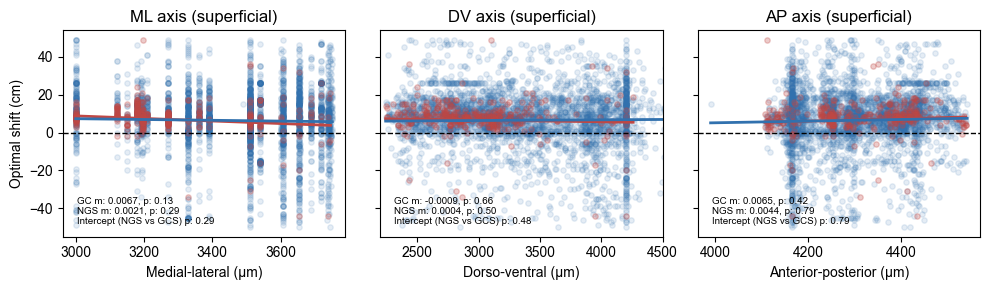

Deep models:
--- ML ---
                                Mixed Linear Model Regression Results
Model:                          MixedLM             Dependent Variable:             optimal_travel_lag
No. Observations:               1756                Method:                         REML              
No. Groups:                     6                   Scale:                          242.3825          
Min. group size:                13                  Log-Likelihood:                 -7413.4587        
Max. group size:                1039                Converged:                      Yes               
Mean group size:                292.7                                                                 
------------------------------------------------------------------------------------------------------
                                                         Coef.  Std.Err.   z    P>|z|  [0.025   0.975]
----------------------------------------------------------------------------------

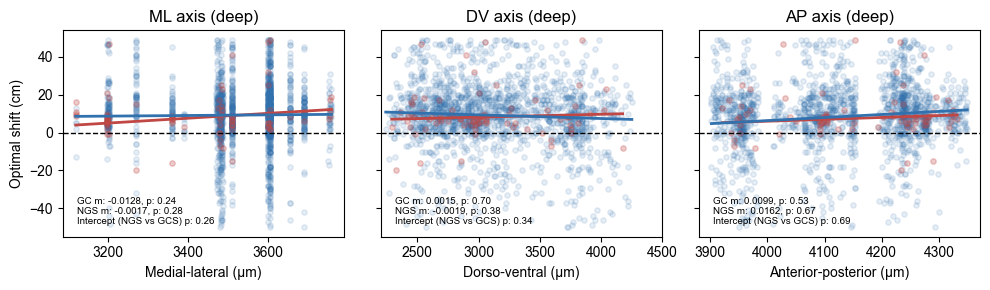

Superficial models:
--- ML ---
                               Mixed Linear Model Regression Results
Model:                        MixedLM             Dependent Variable:             optimal_travel_lag
No. Observations:             3622                Method:                         REML              
No. Groups:                   7                   Scale:                          192.3239          
Min. group size:              211                 Log-Likelihood:                 -14815.2029       
Max. group size:              892                 Converged:                      Yes               
Mean group size:              517.4                                                                 
----------------------------------------------------------------------------------------------------
                                                         Coef.  Std.Err.   z    P>|z|  [0.025 0.975]
--------------------------------------------------------------------------------------------

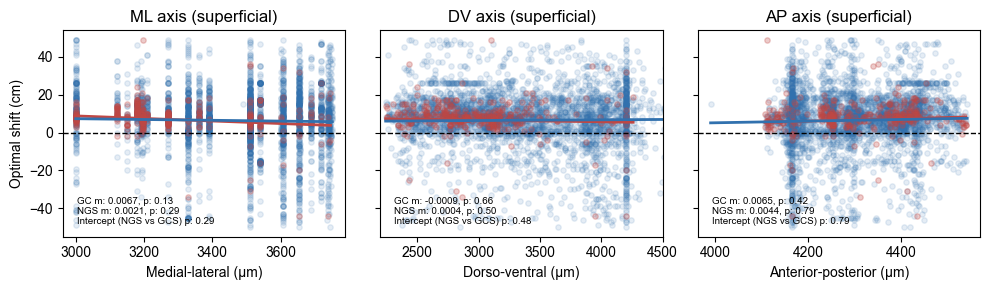

Deep models:
--- ML ---
                                Mixed Linear Model Regression Results
Model:                          MixedLM             Dependent Variable:             optimal_travel_lag
No. Observations:               1756                Method:                         REML              
No. Groups:                     6                   Scale:                          242.3825          
Min. group size:                13                  Log-Likelihood:                 -7413.4587        
Max. group size:                1039                Converged:                      Yes               
Mean group size:                292.7                                                                 
------------------------------------------------------------------------------------------------------
                                                         Coef.  Std.Err.   z    P>|z|  [0.025   0.975]
----------------------------------------------------------------------------------

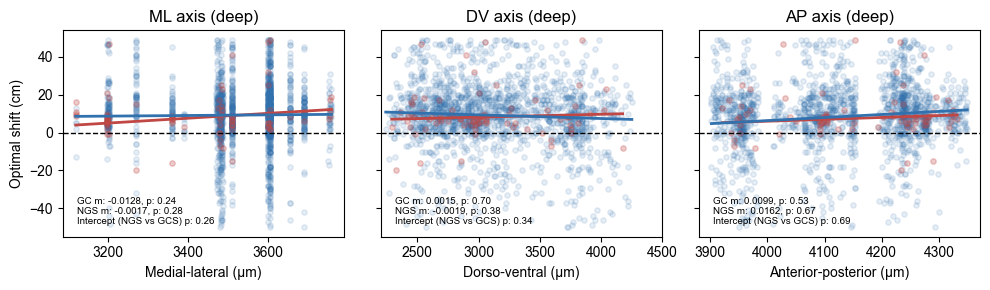

In [ ]:
# ...existing code...
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf

# Prepare data (reuse existing gcs_ / ngs_)
gcs_df = gcs_.copy()
ngs_df = ngs_.copy()

# Keep only ENT and set consistent group labels
gcs_df = gcs_df[gcs_df['brain_region'].str.contains('ENT')].copy()
ngs_df = ngs_df[ngs_df['brain_region'].str.contains('ENT')].copy()

gcs_df['group'] = 'GCS'
ngs_df['group'] = 'NGS'

# Ensure group is categorical with explicit reference 'GCS'
gcs_df['group'] = pd.Categorical(gcs_df['group'], categories=['GCS', 'NGS'])
ngs_df['group'] = pd.Categorical(ngs_df['group'], categories=['GCS', 'NGS'])

# Define superficial / deep sublayer lists
superficial_layers = ['ENTm1', 'ENTm2', 'ENTm3']
deep_layers = ['ENTm5', 'ENTm6', 'ENTl6a']

# Utility to safely get params/pvalues with multiple possible naming conventions
def safe_param(d, *keys, default=np.nan):
    for k in keys:
        if k in d:
            return d[k]
    return default

# Utility: run LMMs for a given combined dataframe and return fitted results
def fit_axis_models(df):
    df = df.copy()
    # ensure categorical and strings for variance components
    df['group'] = pd.Categorical(df['group'], categories=['GCS', 'NGS'])
    df['cluster_id'] = df['cluster_id'].astype(str)
    df['day'] = df['day'].astype(str)
    df['mouse'] = df['mouse'].astype(str)
    vc = {"day": "0 + C(day)", "cluster": "0 + C(cluster_id)"}

    results = {}
    # use explicit categorical coding so intercept difference is C(group,...)[T.NGS]
    for col, name in [('coord_SCs_x', 'ML'), ('coord_SCs_y', 'DV'), ('coord_SCs_z', 'AP')]:
        df_axis = df.dropna(subset=[col])
        if len(df_axis) == 0:
            results[name] = None
            continue
        formula = f"optimal_travel_lag ~ C(group, Treatment(reference='GCS')) * {col}"
        model = smf.mixedlm(formula, df_axis, groups=df_axis["mouse"], vc_formula=vc)
        try:
            res = model.fit()
        except Exception:
            try:
                res = model.fit(method='powell', maxiter=2000, disp=False)
            except Exception:
                res = None
        results[name] = res
    return results

# Utility: plot scatter + fitted lines (with intercept comparison annotation)
def plot_scatter_fits(gcs_sub, ngs_sub, results, outpath, title_suffix):
    fig, axes = plt.subplots(1, 3, figsize=(10, 3), sharey=True)

    # ML: plotting uses inverted x (-1) relative to model fit for display only
    axes[0].scatter(ngs_sub['coord_SCs_x'] * -1, ngs_sub['optimal_travel_lag'], color='#3171ae', alpha=0.12, s=15, label='NGS')
    axes[0].scatter(gcs_sub['coord_SCs_x'] * -1, gcs_sub['optimal_travel_lag'], color='#c04744', alpha=0.28, s=15, label='GCS')
    axes[0].axhline(0, color='black', linestyle='--', linewidth=1)
    axes[0].set_xlabel('Medial-lateral (µm)')
    axes[0].set_ylabel('Optimal shift (cm)')
    axes[0].set_title(f'ML axis ({title_suffix})')

    res_ml = results.get('ML')
    if res_ml is not None:
        p_intercept_key = "C(group, Treatment(reference='GCS'))[T.NGS]"
        p_interact_key = f"{p_intercept_key}:{'coord_SCs_x'}"
        ml_intercept = safe_param(res_ml.params, 'Intercept')
        ml_gcs_slope = safe_param(res_ml.params, 'coord_SCs_x')
        ml_ngs_slope = ml_gcs_slope + safe_param(res_ml.params, p_interact_key, f'group[T.NGS]:coord_SCs_x', 0)
        ml_ngs_intercept = ml_intercept + safe_param(res_ml.params, p_intercept_key, 'group[T.NGS]', 0)
        ml_gcs_p = safe_param(res_ml.pvalues, 'coord_SCs_x')
        ml_ngs_p = safe_param(res_ml.pvalues, p_interact_key, 'group[T.NGS]:coord_SCs_x', default=np.nan)
        ml_intercept_p = safe_param(res_ml.pvalues, p_intercept_key, 'group[T.NGS]')

        ml_x_gcs = np.linspace((gcs_sub['coord_SCs_x'] * -1).min(), (gcs_sub['coord_SCs_x'] * -1).max(), 100)
        ml_x_ngs = np.linspace((ngs_sub['coord_SCs_x'] * -1).min(), (ngs_sub['coord_SCs_x'] * -1).max(), 100)
        # model used raw coord_SCs_x; plotting inverts x so multiply by -1 when evaluating model lines
        axes[0].plot(ml_x_gcs, ml_intercept + ml_gcs_slope * (-ml_x_gcs), color='#c04744', linewidth=2)
        axes[0].plot(ml_x_ngs, ml_ngs_intercept + ml_ngs_slope * (-ml_x_ngs), color='#3171ae', linewidth=2)
        axes[0].text(0.05, 0.05,
                     f"GC m: {ml_gcs_slope:.4f}, p: {ml_gcs_p:.2f}\n"
                     f"NGS m: {ml_ngs_slope:.4f}, p: {ml_ngs_p:.2f}\n"
                     f"Intercept (NGS vs GCS) p: {ml_intercept_p:.2g}",
                     ha='left', va='bottom', fontsize=7, transform=axes[0].transAxes)

    # DV
    axes[1].scatter(ngs_sub['coord_SCs_y'], ngs_sub['optimal_travel_lag'], color='#3171ae', alpha=0.12, s=15)
    axes[1].scatter(gcs_sub['coord_SCs_y'], gcs_sub['optimal_travel_lag'], color='#c04744', alpha=0.28, s=15)
    axes[1].axhline(0, color='black', linestyle='--', linewidth=1)
    axes[1].set_xlabel('Dorso-ventral (µm)')
    axes[1].set_title(f'DV axis ({title_suffix})')
    axes[1].set_xlim(2200, 4500)

    res_dv = results.get('DV')
    if res_dv is not None:
        p_intercept_key = "C(group, Treatment(reference='GCS'))[T.NGS]"
        p_interact_key = f"{p_intercept_key}:{'coord_SCs_y'}"
        dv_intercept = safe_param(res_dv.params, 'Intercept')
        dv_gcs_slope = safe_param(res_dv.params, 'coord_SCs_y')
        dv_ngs_slope = dv_gcs_slope + safe_param(res_dv.params, p_interact_key, f'group[T.NGS]:coord_SCs_y', 0)
        dv_ngs_intercept = dv_intercept + safe_param(res_dv.params, p_intercept_key, 'group[T.NGS]', 0)
        dv_gcs_p = safe_param(res_dv.pvalues, 'coord_SCs_y')
        dv_ngs_p = safe_param(res_dv.pvalues, p_interact_key, 'group[T.NGS]:coord_SCs_y', default=np.nan)
        dv_intercept_p = safe_param(res_dv.pvalues, p_intercept_key, 'group[T.NGS]')

        dv_x_gcs = np.linspace(gcs_sub['coord_SCs_y'].min(), gcs_sub['coord_SCs_y'].max(), 100)
        dv_x_ngs = np.linspace(ngs_sub['coord_SCs_y'].min(), ngs_sub['coord_SCs_y'].max(), 100)
        axes[1].plot(dv_x_gcs, dv_intercept + dv_gcs_slope * dv_x_gcs, color='#c04744', linewidth=2)
        axes[1].plot(dv_x_ngs, dv_ngs_intercept + dv_ngs_slope * dv_x_ngs, color='#3171ae', linewidth=2)
        axes[1].text(0.05, 0.05,
                     f"GC m: {dv_gcs_slope:.4f}, p: {dv_gcs_p:.2f}\n"
                     f"NGS m: {dv_ngs_slope:.4f}, p: {dv_ngs_p:.2f}\n"
                     f"Intercept (NGS vs GCS) p: {dv_intercept_p:.2g}",
                     ha='left', va='bottom', fontsize=7, transform=axes[1].transAxes)

    # AP
    axes[2].scatter(ngs_sub['coord_SCs_z'], ngs_sub['optimal_travel_lag'], color='#3171ae', alpha=0.12, s=15)
    axes[2].scatter(gcs_sub['coord_SCs_z'], gcs_sub['optimal_travel_lag'], color='#c04744', alpha=0.28, s=15)
    axes[2].axhline(0, color='black', linestyle='--', linewidth=1)
    axes[2].set_xlabel('Anterior-posterior (µm)')
    axes[2].set_title(f'AP axis ({title_suffix})')

    res_ap = results.get('AP')
    if res_ap is not None:
        p_intercept_key = "C(group, Treatment(reference='GCS'))[T.NGS]"
        p_interact_key = f"{p_intercept_key}:{'coord_SCs_z'}"
        ap_intercept = safe_param(res_ap.params, 'Intercept')
        ap_gcs_slope = safe_param(res_ap.params, 'coord_SCs_z')
        ap_ngs_slope = ap_gcs_slope + safe_param(res_ap.params, p_interact_key, f'group[T.NGS]:coord_SCs_z', 0)
        ap_ngs_intercept = ap_intercept + safe_param(res_ap.params, p_intercept_key, 'group[T.NGS]', 0)
        ap_gcs_p = safe_param(res_ap.pvalues, 'coord_SCs_z')
        ap_ngs_p = safe_param(res_ap.pvalues, p_interact_key, 'group[T.NGS]:coord_SCs_z', default=np.nan)
        ap_intercept_p = safe_param(res_ap.pvalues, p_intercept_key, 'group[T.NGS]')

        ap_x_gcs = np.linspace(gcs_sub['coord_SCs_z'].min(), gcs_sub['coord_SCs_z'].max(), 100)
        ap_x_ngs = np.linspace(ngs_sub['coord_SCs_z'].min(), ngs_sub['coord_SCs_z'].max(), 100)
        axes[2].plot(ap_x_gcs, ap_intercept + ap_gcs_slope * ap_x_gcs, color='#c04744', linewidth=2)
        axes[2].plot(ap_x_ngs, ap_ngs_intercept + ap_ngs_slope * ap_x_ngs, color='#3171ae', linewidth=2)
        axes[2].text(0.05, 0.05,
                     f"GC m: {ap_gcs_slope:.4f}, p: {ap_gcs_p:.2f}\n"
                     f"NGS m: {ap_ngs_slope:.4f}, p: {ap_ngs_p:.2f}\n"
                     f"Intercept (NGS vs GCS) p: {ap_intercept_p:.2g}",
                     ha='left', va='bottom', fontsize=7, transform=axes[2].transAxes)

    plt.tight_layout()
    plt.savefig(outpath, bbox_inches='tight')
    plt.show()
    plt.close(fig)

# --- Version A: Superficial only ---
gcs_superficial = gcs_df[gcs_df['brain_region'].isin(superficial_layers)].copy()
ngs_superficial = ngs_df[ngs_df['brain_region'].isin(superficial_layers)].copy()
combined_superficial = pd.concat([gcs_superficial, ngs_superficial], ignore_index=True)
# ensure categorical ordering
combined_superficial['group'] = pd.Categorical(combined_superficial['group'], categories=['GCS','NGS'])

results_superficial = fit_axis_models(combined_superficial)

print("Superficial models:")
for axis_name, res in results_superficial.items():
    print(f"--- {axis_name} ---")
    if res is None:
        print("No result")
    else:
        print(res.summary())

plot_scatter_fits(
    gcs_superficial, ngs_superficial, results_superficial,
    '/Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_2_predictive_coding/optimal_lag_by_axis_superficial_scatterfits.pdf',
    'superficial'
)

# --- Version B: Deep only ---
gcs_deep = gcs_df[gcs_df['brain_region'].isin(deep_layers)].copy()
ngs_deep = ngs_df[ngs_df['brain_region'].isin(deep_layers)].copy()
combined_deep = pd.concat([gcs_deep, ngs_deep], ignore_index=True)
combined_deep['group'] = pd.Categorical(combined_deep['group'], categories=['GCS','NGS'])

results_deep = fit_axis_models(combined_deep)

print("Deep models:")
for axis_name, res in results_deep.items():
    print(f"--- {axis_name} ---")
    if res is None:
        print("No result")
    else:
        print(res.summary())

plot_scatter_fits(
    gcs_deep, ngs_deep, results_deep,
    '/Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_2_predictive_coding/optimal_lag_by_axis_deep_scatterfits.pdf',
    'deep'
)
 
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf

# Prepare data (reuse existing gcs_ / ngs_)
gcs_df = gcs_.copy()
ngs_df = ngs_.copy()

# Keep only ENT and set consistent group labels
gcs_df = gcs_df[gcs_df['brain_region'].str.contains('ENT')].copy()
ngs_df = ngs_df[ngs_df['brain_region'].str.contains('ENT')].copy()

gcs_df['group'] = 'GCS'
ngs_df['group'] = 'NGS'

# Ensure group is categorical with explicit reference 'GCS'
gcs_df['group'] = pd.Categorical(gcs_df['group'], categories=['GCS', 'NGS'])
ngs_df['group'] = pd.Categorical(ngs_df['group'], categories=['GCS', 'NGS'])

# Define superficial / deep sublayer lists
superficial_layers = ['ENTm1', 'ENTm2', 'ENTm3']
deep_layers = ['ENTm5', 'ENTm6', 'ENTl6a']

# Utility to safely get params/pvalues with multiple possible naming conventions
def safe_param(d, *keys, default=np.nan):
    for k in keys:
        if k in d:
            return d[k]
    return default

# Utility: run LMMs for a given combined dataframe and return fitted results
def fit_axis_models(df):
    df = df.copy()
    # ensure categorical and strings for variance components
    df['group'] = pd.Categorical(df['group'], categories=['GCS', 'NGS'])
    df['cluster_id'] = df['cluster_id'].astype(str)
    df['day'] = df['day'].astype(str)
    df['mouse'] = df['mouse'].astype(str)
    vc = {"day": "0 + C(day)", "cluster": "0 + C(cluster_id)"}

    results = {}
    # use explicit categorical coding so intercept difference is C(group,...)[T.NGS]
    for col, name in [('coord_SCs_x', 'ML'), ('coord_SCs_y', 'DV'), ('coord_SCs_z', 'AP')]:
        df_axis = df.dropna(subset=[col])
        if len(df_axis) == 0:
            results[name] = None
            continue
        formula = f"optimal_travel_lag ~ C(group, Treatment(reference='GCS')) * {col}"
        model = smf.mixedlm(formula, df_axis, groups=df_axis["mouse"], vc_formula=vc)
        try:
            res = model.fit()
        except Exception:
            try:
                res = model.fit(method='powell', maxiter=2000, disp=False)
            except Exception:
                res = None
        results[name] = res
    return results

# Utility: plot scatter + fitted lines (with intercept comparison annotation)
def plot_scatter_fits(gcs_sub, ngs_sub, results, outpath, title_suffix):
    fig, axes = plt.subplots(1, 3, figsize=(10, 3), sharey=True)

    # ML: plotting uses inverted x (-1) relative to model fit for display only
    axes[0].scatter(ngs_sub['coord_SCs_x'] * -1, ngs_sub['optimal_travel_lag'], color='#3171ae', alpha=0.12, s=15, label='NGS')
    axes[0].scatter(gcs_sub['coord_SCs_x'] * -1, gcs_sub['optimal_travel_lag'], color='#c04744', alpha=0.28, s=15, label='GCS')
    axes[0].axhline(0, color='black', linestyle='--', linewidth=1)
    axes[0].set_xlabel('Medial-lateral (µm)')
    axes[0].set_ylabel('Optimal shift (cm)')
    axes[0].set_title(f'ML axis ({title_suffix})')

    res_ml = results.get('ML')
    if res_ml is not None:
        p_intercept_key = "C(group, Treatment(reference='GCS'))[T.NGS]"
        p_interact_key = f"{p_intercept_key}:{'coord_SCs_x'}"
        ml_intercept = safe_param(res_ml.params, 'Intercept')
        ml_gcs_slope = safe_param(res_ml.params, 'coord_SCs_x')
        ml_ngs_slope = ml_gcs_slope + safe_param(res_ml.params, p_interact_key, f'group[T.NGS]:coord_SCs_x', 0)
        ml_ngs_intercept = ml_intercept + safe_param(res_ml.params, p_intercept_key, 'group[T.NGS]', 0)
        ml_gcs_p = safe_param(res_ml.pvalues, 'coord_SCs_x')
        ml_ngs_p = safe_param(res_ml.pvalues, p_interact_key, 'group[T.NGS]:coord_SCs_x', default=np.nan)
        ml_intercept_p = safe_param(res_ml.pvalues, p_intercept_key, 'group[T.NGS]')

        ml_x_gcs = np.linspace((gcs_sub['coord_SCs_x'] * -1).min(), (gcs_sub['coord_SCs_x'] * -1).max(), 100)
        ml_x_ngs = np.linspace((ngs_sub['coord_SCs_x'] * -1).min(), (ngs_sub['coord_SCs_x'] * -1).max(), 100)
        # model used raw coord_SCs_x; plotting inverts x so multiply by -1 when evaluating model lines
        axes[0].plot(ml_x_gcs, ml_intercept + ml_gcs_slope * (-ml_x_gcs), color='#c04744', linewidth=2)
        axes[0].plot(ml_x_ngs, ml_ngs_intercept + ml_ngs_slope * (-ml_x_ngs), color='#3171ae', linewidth=2)
        axes[0].text(0.05, 0.05,
                     f"GC m: {ml_gcs_slope:.4f}, p: {ml_gcs_p:.2f}\n"
                     f"NGS m: {ml_ngs_slope:.4f}, p: {ml_ngs_p:.2f}\n"
                     f"Intercept (NGS vs GCS) p: {ml_intercept_p:.2g}",
                     ha='left', va='bottom', fontsize=7, transform=axes[0].transAxes)

    # DV
    axes[1].scatter(ngs_sub['coord_SCs_y'], ngs_sub['optimal_travel_lag'], color='#3171ae', alpha=0.12, s=15)
    axes[1].scatter(gcs_sub['coord_SCs_y'], gcs_sub['optimal_travel_lag'], color='#c04744', alpha=0.28, s=15)
    axes[1].axhline(0, color='black', linestyle='--', linewidth=1)
    axes[1].set_xlabel('Dorso-ventral (µm)')
    axes[1].set_title(f'DV axis ({title_suffix})')
    axes[1].set_xlim(2200, 4500)

    res_dv = results.get('DV')
    if res_dv is not None:
        p_intercept_key = "C(group, Treatment(reference='GCS'))[T.NGS]"
        p_interact_key = f"{p_intercept_key}:{'coord_SCs_y'}"
        dv_intercept = safe_param(res_dv.params, 'Intercept')
        dv_gcs_slope = safe_param(res_dv.params, 'coord_SCs_y')
        dv_ngs_slope = dv_gcs_slope + safe_param(res_dv.params, p_interact_key, f'group[T.NGS]:coord_SCs_y', 0)
        dv_ngs_intercept = dv_intercept + safe_param(res_dv.params, p_intercept_key, 'group[T.NGS]', 0)
        dv_gcs_p = safe_param(res_dv.pvalues, 'coord_SCs_y')
        dv_ngs_p = safe_param(res_dv.pvalues, p_interact_key, 'group[T.NGS]:coord_SCs_y', default=np.nan)
        dv_intercept_p = safe_param(res_dv.pvalues, p_intercept_key, 'group[T.NGS]')

        dv_x_gcs = np.linspace(gcs_sub['coord_SCs_y'].min(), gcs_sub['coord_SCs_y'].max(), 100)
        dv_x_ngs = np.linspace(ngs_sub['coord_SCs_y'].min(), ngs_sub['coord_SCs_y'].max(), 100)
        axes[1].plot(dv_x_gcs, dv_intercept + dv_gcs_slope * dv_x_gcs, color='#c04744', linewidth=2)
        axes[1].plot(dv_x_ngs, dv_ngs_intercept + dv_ngs_slope * dv_x_ngs, color='#3171ae', linewidth=2)
        axes[1].text(0.05, 0.05,
                     f"GC m: {dv_gcs_slope:.4f}, p: {dv_gcs_p:.2f}\n"
                     f"NGS m: {dv_ngs_slope:.4f}, p: {dv_ngs_p:.2f}\n"
                     f"Intercept (NGS vs GCS) p: {dv_intercept_p:.2g}",
                     ha='left', va='bottom', fontsize=7, transform=axes[1].transAxes)

    # AP
    axes[2].scatter(ngs_sub['coord_SCs_z'], ngs_sub['optimal_travel_lag'], color='#3171ae', alpha=0.12, s=15)
    axes[2].scatter(gcs_sub['coord_SCs_z'], gcs_sub['optimal_travel_lag'], color='#c04744', alpha=0.28, s=15)
    axes[2].axhline(0, color='black', linestyle='--', linewidth=1)
    axes[2].set_xlabel('Anterior-posterior (µm)')
    axes[2].set_title(f'AP axis ({title_suffix})')

    res_ap = results.get('AP')
    if res_ap is not None:
        p_intercept_key = "C(group, Treatment(reference='GCS'))[T.NGS]"
        p_interact_key = f"{p_intercept_key}:{'coord_SCs_z'}"
        ap_intercept = safe_param(res_ap.params, 'Intercept')
        ap_gcs_slope = safe_param(res_ap.params, 'coord_SCs_z')
        ap_ngs_slope = ap_gcs_slope + safe_param(res_ap.params, p_interact_key, f'group[T.NGS]:coord_SCs_z', 0)
        ap_ngs_intercept = ap_intercept + safe_param(res_ap.params, p_intercept_key, 'group[T.NGS]', 0)
        ap_gcs_p = safe_param(res_ap.pvalues, 'coord_SCs_z')
        ap_ngs_p = safe_param(res_ap.pvalues, p_interact_key, 'group[T.NGS]:coord_SCs_z', default=np.nan)
        ap_intercept_p = safe_param(res_ap.pvalues, p_intercept_key, 'group[T.NGS]')

        ap_x_gcs = np.linspace(gcs_sub['coord_SCs_z'].min(), gcs_sub['coord_SCs_z'].max(), 100)
        ap_x_ngs = np.linspace(ngs_sub['coord_SCs_z'].min(), ngs_sub['coord_SCs_z'].max(), 100)
        axes[2].plot(ap_x_gcs, ap_intercept + ap_gcs_slope * ap_x_gcs, color='#c04744', linewidth=2)
        axes[2].plot(ap_x_ngs, ap_ngs_intercept + ap_ngs_slope * ap_x_ngs, color='#3171ae', linewidth=2)
        axes[2].text(0.05, 0.05,
                     f"GC m: {ap_gcs_slope:.4f}, p: {ap_gcs_p:.2f}\n"
                     f"NGS m: {ap_ngs_slope:.4f}, p: {ap_ngs_p:.2f}\n"
                     f"Intercept (NGS vs GCS) p: {ap_intercept_p:.2g}",
                     ha='left', va='bottom', fontsize=7, transform=axes[2].transAxes)

    plt.tight_layout()
    plt.savefig(outpath, bbox_inches='tight')
    plt.show()
    plt.close(fig)

# --- Version A: Superficial only ---
gcs_superficial = gcs_df[gcs_df['brain_region'].isin(superficial_layers)].copy()
ngs_superficial = ngs_df[ngs_df['brain_region'].isin(superficial_layers)].copy()
combined_superficial = pd.concat([gcs_superficial, ngs_superficial], ignore_index=True)
# ensure categorical ordering
combined_superficial['group'] = pd.Categorical(combined_superficial['group'], categories=['GCS','NGS'])

results_superficial = fit_axis_models(combined_superficial)

print("Superficial models:")
for axis_name, res in results_superficial.items():
    print(f"--- {axis_name} ---")
    if res is None:
        print("No result")
    else:
        print(res.summary())

plot_scatter_fits(
    gcs_superficial, ngs_superficial, results_superficial,
    '/Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_2_predictive_coding/optimal_lag_by_axis_superficial_scatterfits.pdf',
    'superficial'
)

# --- Version B: Deep only ---
gcs_deep = gcs_df[gcs_df['brain_region'].isin(deep_layers)].copy()
ngs_deep = ngs_df[ngs_df['brain_region'].isin(deep_layers)].copy()
combined_deep = pd.concat([gcs_deep, ngs_deep], ignore_index=True)
combined_deep['group'] = pd.Categorical(combined_deep['group'], categories=['GCS','NGS'])

results_deep = fit_axis_models(combined_deep)

print("Deep models:")
for axis_name, res in results_deep.items():
    print(f"--- {axis_name} ---")
    if res is None:
        print("No result")
    else:
        print(res.summary())

plot_scatter_fits(
    gcs_deep, ngs_deep, results_deep,
    '/Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_2_predictive_coding/optimal_lag_by_axis_deep_scatterfits.pdf',
    'deep'
)
# ...existing code...